# LangGraph পরিচিতি 

এই নোটবুকে আমরা LangGraph-এর একদম শুরুর ধারণাগুলো শিখব। LangGraph হলো LangChain-এর একটি এক্সটেনশন যেটি দিয়ে AI agent-দের জন্য **graph-based workflow** তৈরি করা যায় — অর্থাৎ কাজকে ছোট ছোট node-এ ভাগ করে, একটি নির্দিষ্ট flow-তে চালানো যায়।

## এই নোটবুকে যা শিখব:

| বিষয় | বিবরণ |
|---|---|
| `AgentState` | Graph-এর মধ্য দিয়ে যে data প্রবাহিত হয় তার structure |
| `StateGraph` | Graph তৈরির মূল class |
| Node | Graph-এর একটি কাজের একক (function) |
| Entry & Finish Point | Graph কোথা থেকে শুরু হবে এবং কোথায় শেষ হবে |
| `compile()` & `invoke()` | Graph চালু করার পদ্ধতি |

**মূল ধারণা:** LangGraph-এ সবকিছু একটি **state**-কে কেন্দ্র করে চলে। প্রতিটি node সেই state পড়ে, পরিবর্তন করে, এবং পরবর্তী node-এ পাঠিয়ে দেয়।

# Single  Node - LangGraph

## Hello World Agent
আমাদের প্রথম LangGraph graph!

### এই অংশে কী হচ্ছে?

প্রথমে দরকারি library import করা হচ্ছে:

- `TypedDict` — Python-এর একটি বিশেষ dictionary type, যেখানে key এবং তার data type আগে থেকে নির্ধারণ করা যায়। LangGraph-এ state define করতে এটি ব্যবহার করা হয়।
- `StateGraph` — LangGraph-এর মূল class। এটি দিয়ে graph তৈরি করা হয়।

**কেন TypedDict?** কারণ LangGraph জানতে চায় state-এ ঠিক কোন কোন field থাকবে এবং তাদের type কী — এতে করে graph চলার সময় type error ধরা সহজ হয়।

In [1]:
from typing import Dict , TypedDict
from langgraph.graph import StateGraph


### State এবং Node তৈরি করা

LangGraph-এ দুটি মূল জিনিস দরকার:

**১. State (অবস্থা):**
State হলো একটি dictionary-এর মতো structure যেটি graph-এর সব node-এর মধ্য দিয়ে প্রবাহিত হয়। এখানে `AgentState`-এ মাত্র একটি field আছে — `message` (string type)।

```
AgentState = { message: কোনো একটি string }
```

**২. Node (কাজের একক):**
Node হলো একটি সাধারণ Python function যেটি:
- Input হিসেবে state নেয়
- state পরিবর্তন করে
- পরিবর্তিত state return করে

এখানে `greeting_node` function-টি `message`-এর শুরুতে Hey  এবং শেষে , How is your day going? যোগ করছে।

**Flow চিত্র:**
```
Input: {message: Rasel}
 ↓
 greeting_node
 ↓
Output: {message: Hey Rasel, How is your day going?}
```

In [2]:
class AgentState(TypedDict):
    message : str


def greeting_node (state : AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message']= "Hey " + state['message'] + ", How is your day going?"

    return state

### Graph তৈরি এবং compile করা

এখানে মূল graph তৈরি করা হচ্ছে। ধাপগুলো হলো:

| ধাপ | Code | কাজ |
|---|---|---|
| ১ | `StateGraph(AgentState)` | নতুন graph তৈরি, state type জানিয়ে দেওয়া |
| ২ | `add_node(greeter, greeting_node)` | graph-এ node যোগ করা, নাম দেওয়া greeter |
| ৩ | `set_entry_point(greeter)` | graph কোথা থেকে শুরু হবে |
| ৪ | `set_finish_point(greeter)` | graph কোথায় শেষ হবে |
| ৫ | `compile()` | graph-কে চালানোর জন্য প্রস্তুত করা |

এই উদাহরণে মাত্র একটি node আছে — তাই শুরু এবং শেষ দুটোই একই node (greeter)।

> **মনে রাখো:** `compile()` না করলে graph চালানো যাবে না। এটি LangGraph-কে বলে দেয় যে graph-এর structure ঠিক আছে এবং চলার জন্য প্রস্তুত।

In [3]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app= graph.compile()

### Graph-এর চিত্র দেখা

LangGraph-এর একটি দারুণ সুবিধা হলো graph-এর visual diagram দেখা যায়।

`app.get_graph().draw_mermaid_png()` — এই method graph-টিকে একটি image-এ পরিণত করে। এই image থেকে বোঝা যায় কোন node-এর পর কোন node আসছে।

এই সিরিজের পরের notebook-গুলোতে যখন graph জটিল হবে (একাধিক node, conditional path), তখন এই visualization আরও বেশি কাজে আসবে।

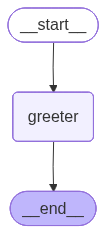

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

### Graph চালানো (invoke করা)

এখন graph-টি বাস্তবে চালানো হচ্ছে `invoke()` method ব্যবহার করে।

`app.invoke()` graph-এর execution শুরু করে এবং input state graph-এর entry point node-এ পাঠায়। এখানে `"message": "Rasel"` পাঠানো হয়েছে, তাই `greeting_node` এই message নিয়ে কাজ করবে।

| ধাপ | Code                   | কাজ                                   |
| --- | ---------------------- | ------------------------------------- |
| ১   | `app.invoke({...})`    | graph execution শুরু করা              |
| ২   | `{"message": "Rasel"}` | graph-এর initial input/state পাঠানো   |
| ৩   | `result = ...`         | graph execution-এর output সংরক্ষণ করা |

এই execution-এর পরে `result` variable-এর মধ্যে graph-এর final state বা output থাকবে।

> **মনে রাখো:** `invoke()` হলো LangGraph চালানোর সবচেয়ে সহজ উপায়। এটি পুরো graph শুরু থেকে শেষ পর্যন্ত execute করে final result return করে।


In [5]:
result= app.invoke({"message": "Rasel"})

In [6]:
result['message']

'Hey Rasel, How is your day going?'